# Saguaro Stem Count Data 2016 - 2026

## Load Data

In [10]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp
from sklearn.linear_model import LinearRegression

In [11]:
# load bud count csv
df = pd.read_csv('Saguaro Bud Counts - Stem Counts.csv')
df = df.drop(columns=['Unnamed: 3'])
df.head()

,Image,Year,Stem Count
0,15,2016,1
1,18,2016,9
2,19,2016,6
3,20,2016,3
4,21,2016,1


## Graph Data

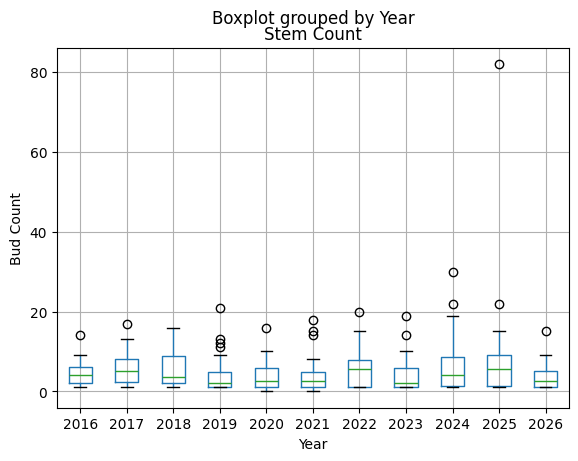

In [12]:
# box plot by year
df.boxplot(column='Stem Count', by='Year')

plt.xlabel("Year")
plt.ylabel("Bud Count")
plt.show()

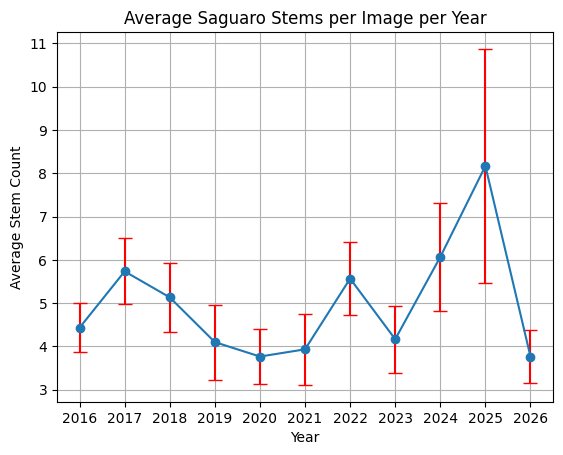

In [13]:
# line plot for mean each year with standard errors
yearly_stems_mean = df.groupby('Year')['Stem Count'].mean()
yearly_stems_se = df.groupby('Year')['Stem Count'].sem()

plt.errorbar(yearly_stems_mean.index, yearly_stems_mean.values, yerr=yearly_stems_se.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Stem Count")
plt.title("Average Saguaro Stems per Image per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

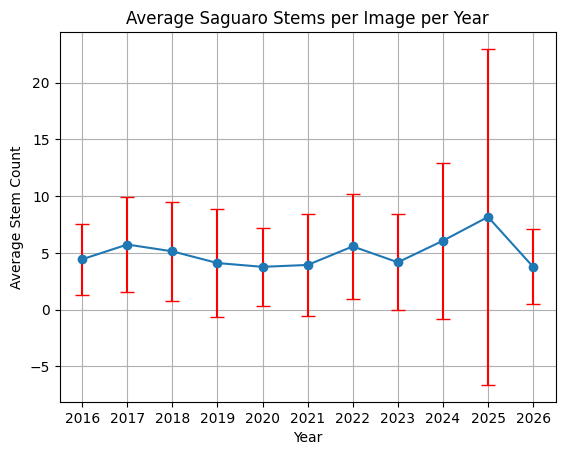

In [14]:
# line plot for mean each year with standard deviation
yearly_stems_std = df.groupby('Year')['Stem Count'].std()

plt.errorbar(yearly_stems_mean.index, yearly_stems_mean.values, yerr=yearly_stems_std.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Stem Count")
plt.title("Average Saguaro Stems per Image per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

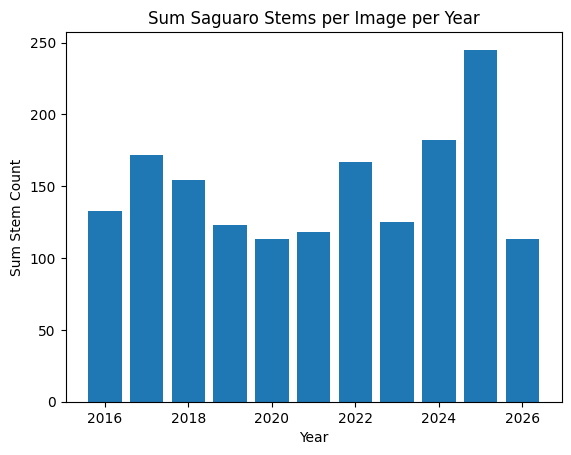

In [15]:
# bar plot for sums each year
yearly_stems_sum = df.groupby('Year')['Stem Count'].sum()

plt.bar(yearly_stems_sum.index, yearly_stems_sum.values)

plt.xlabel("Year")
plt.ylabel("Sum Stem Count")
plt.title("Sum Saguaro Stems per Image per Year")
plt.show()

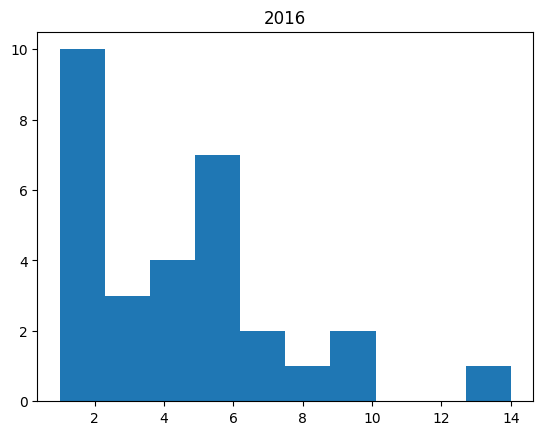

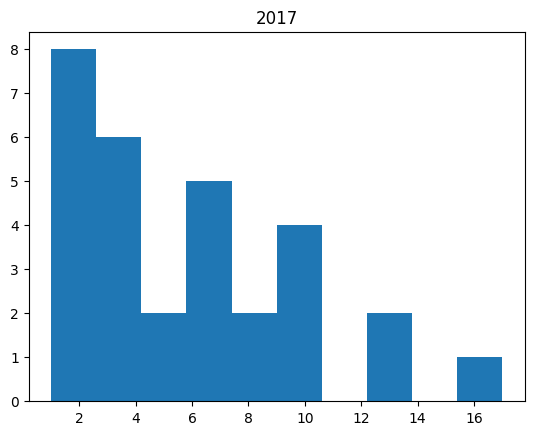

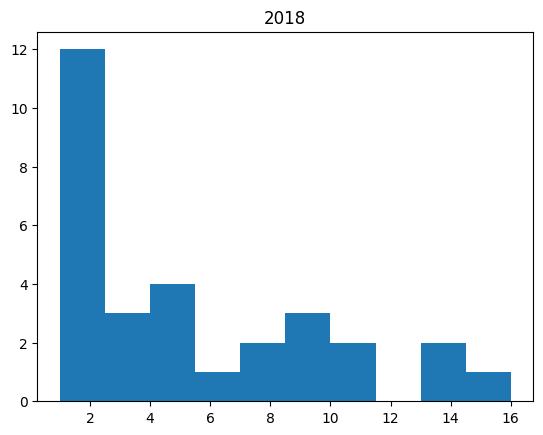

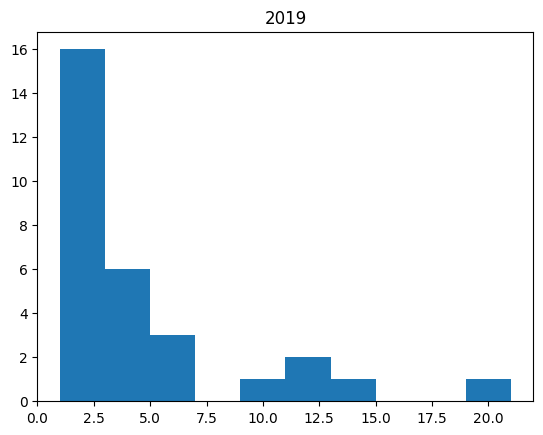

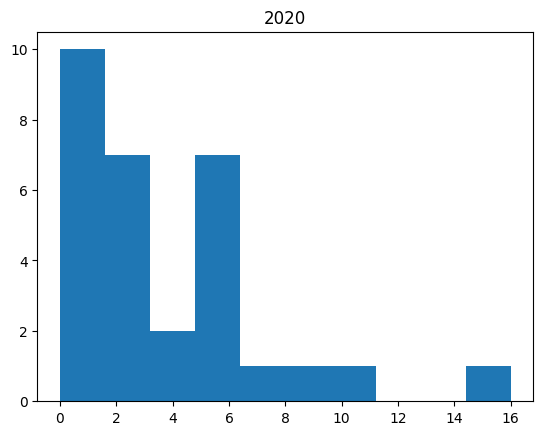

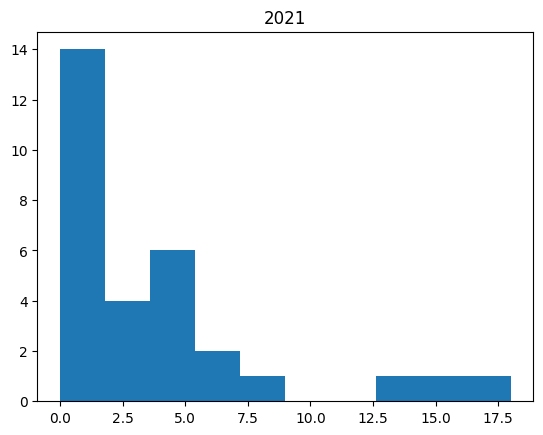

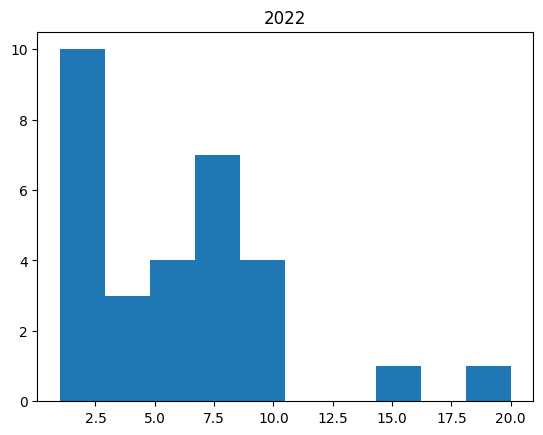

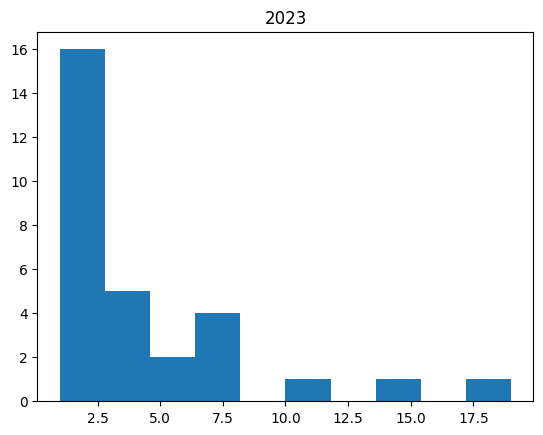

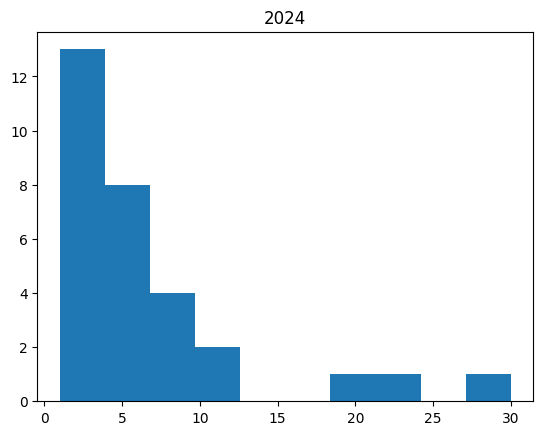

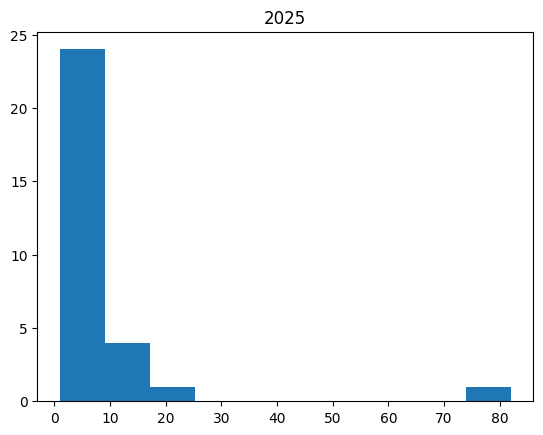

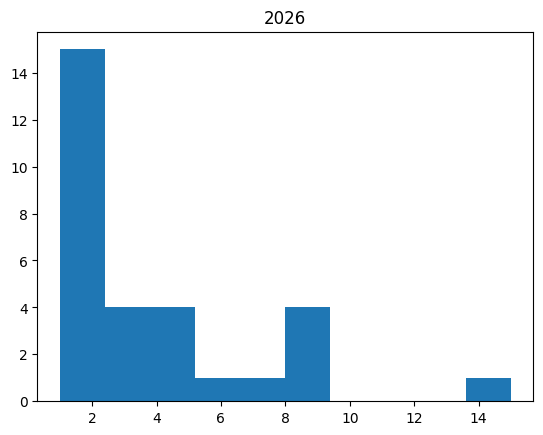

In [16]:
# make a histogram of each year 
for i in df.Year.unique():
    plt.hist(df[df['Year'] == i]['Stem Count'])
    plt.title(i)
    plt.show()

## Statistical Analysis

In [17]:
# check if anova test is valid
# check normality
model = LinearRegression()
model.fit(df[['Year']], df[['Stem Count']])

predictions = model.predict(df[['Year']])
residuals = df[['Stem Count']] - predictions

stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)

# check homogeneity of variances
stems_2016 = df.loc[df['Year'] == 2016, 'Stem Count']
stems_2017 = df.loc[df['Year'] == 2017, 'Stem Count']
stems_2018 = df.loc[df['Year'] == 2018, 'Stem Count']
stems_2019 = df.loc[df['Year'] == 2019, 'Stem Count']
stems_2020 = df.loc[df['Year'] == 2020, 'Stem Count']
stems_2021 = df.loc[df['Year'] == 2021, 'Stem Count']
stems_2022 = df.loc[df['Year'] == 2022, 'Stem Count']
stems_2023 = df.loc[df['Year'] == 2023, 'Stem Count']
stems_2024 = df.loc[df['Year'] == 2024, 'Stem Count']
stems_2025 = df.loc[df['Year'] == 2025, 'Stem Count']
stems_2026 = df.loc[df['Year'] == 2026, 'Stem Count']
data = [stems_2016, stems_2017, stems_2018, stems_2019, stems_2020, stems_2021, stems_2022, stems_2023, stems_2024, stems_2025, stems_2026]

stat1, p1 = stats.levene(stems_2016, stems_2017, stems_2018, stems_2019, stems_2020, stems_2021, stems_2022, stems_2023, stems_2024, stems_2025, stems_2026)
print("Levene's p-value:", p1)

Shapiro-Wilk p-value: 2.221068005497154e-27
Levene's p-value: 0.21616150367555514


Since the Shapiro Wilk p-value is less than 0.05, the data is not normally distributed. On the other hand, since the Levene's p-value is greater than 0.05 the data has homogeneity of variances meaning that we can use a parametric test on the data. 

In [18]:
# continue with anova 
f_stat, p2 = stats.f_oneway(stems_2016, stems_2017, stems_2018, stems_2019, stems_2020, stems_2021, stems_2022, stems_2023, stems_2024, stems_2025, stems_2026)
print("f-statistic:", f_stat)
print("p-value:", p2)

f-statistic: 1.4272665412259944
p-value: 0.16685658094659903


Since the p-value is greater than 0.05, this means that there is not a significant difference between the means of stems in each image each year.